# Configuration


In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gc
import os
import glob
import json
from typing import List, Dict, Any, Tuple
from datetime import datetime, date
import random

In [2]:
# Run this once (only once) everytime you opened jupyter notebook
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [3]:
# Set up Random SEED
SEED = 100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load Stock Data


In [4]:
# Load dataset from a specific TICKER
TICKER = "AAPL"
X_raw = pd.read_csv(f"../data/selected/{TICKER}_X.csv")
y_raw = pd.read_csv(f"../data/selected/{TICKER}_y.csv")

In [5]:
dates = pd.to_datetime(X_raw["date"])
X = X_raw.drop(columns="date").values
y = np.ravel(y_raw.values)

# Create Time Series Split for CV


In [6]:
'''
Generates training and testing indices on each time-series-split data

Args:
    data: dataset (or feature matrix) of a stock to split.
    n_splits: Number of folds.
    test_size: Size of each test set.
    gap: Number of samples to exclude between train and test.

Returns:
    List of dicts with keys: (1) "fold": fold number, 0-based (2) "train_idx": training indices (3) "test_idx": testing indices
'''
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 50):
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx,  
            "test_idx": test_idx,
        })
    return folds

In [7]:
folds = createTimeSeriesSplit(data=X)
# folds

# XGBoost


In [8]:
'''
Perform Time-Series CV on a XGBoost model
Args: 
    base_params: the base parameters of the xgboost model
    folds: created from time series split
    X: a numpy ndarray feature matrix (shape: [n_samples, n_features])
    y: a numpy 1d array target vector (shape: [n_features])
    dates: a pandas series containing all the datetimes
    debug: option to whether include train and test rmse through epochs (default False)
Returns: 
    model predictions, actual results, and rmse scores on each time-series-split test set (there is a list of them)
'''
def train_xgb(base_params=None, folds=None, X=None, y=None, dates=None, debug=False):

    # Use default one if user did not provide hyperparameters (FEEL FREE TO ADD MORE!)
    if not base_params:
        base_params = { 
            "n_estimators": 1000,
            "max_depth": 4,
            "learning_rate": 0.01,
            "subsample": 0.7,
            "colsample_bytree": 0.7,
            "min_child_weight": 1,
            "reg_alpha": 0.1,
            "reg_lambda": 0.5,
            "random_state":SEED,
            "objective":'reg:squarederror',
        }
    verbose = 0 if not debug else 100 # debug or no?

    preds, tests = [], []
    scores = []
    
    for fold in folds:
        train_idx, test_idx = fold["train_idx"], fold["test_idx"]
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
            
        reg = xgb.XGBRegressor(**base_params)
        reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=verbose)
        
        y_pred = reg.predict(X_test)
        
        tests.append(pd.Series(y_test, index=dates[test_idx]))
        preds.append(pd.Series(y_pred, index=dates[test_idx]))
        score = root_mean_squared_error(y_test, y_pred)
        scores.append(score)

    return preds, tests, scores

In [9]:
preds_xgb, tests_xgb, scores_xgb = train_xgb(folds=folds, X=X, y=y, dates=dates, debug=True)
print(f"CV Error: {np.mean(scores_xgb):.4f}")

[0]	validation_0-rmse:0.01942	validation_1-rmse:0.01209
[100]	validation_0-rmse:0.01827	validation_1-rmse:0.01207
[200]	validation_0-rmse:0.01747	validation_1-rmse:0.01204
[300]	validation_0-rmse:0.01681	validation_1-rmse:0.01201
[400]	validation_0-rmse:0.01626	validation_1-rmse:0.01203
[500]	validation_0-rmse:0.01574	validation_1-rmse:0.01206
[600]	validation_0-rmse:0.01529	validation_1-rmse:0.01207
[700]	validation_0-rmse:0.01488	validation_1-rmse:0.01208
[800]	validation_0-rmse:0.01448	validation_1-rmse:0.01209
[900]	validation_0-rmse:0.01413	validation_1-rmse:0.01213
[999]	validation_0-rmse:0.01380	validation_1-rmse:0.01214
[0]	validation_0-rmse:0.01908	validation_1-rmse:0.01725
[100]	validation_0-rmse:0.01796	validation_1-rmse:0.01735
[200]	validation_0-rmse:0.01721	validation_1-rmse:0.01743
[300]	validation_0-rmse:0.01659	validation_1-rmse:0.01749
[400]	validation_0-rmse:0.01605	validation_1-rmse:0.01758
[500]	validation_0-rmse:0.01556	validation_1-rmse:0.01757
[600]	validation_0

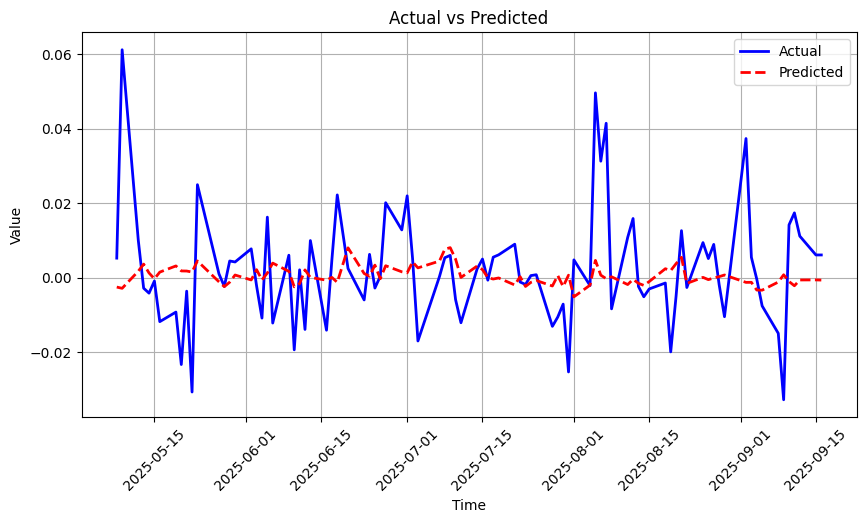

In [10]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_xgb[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_xgb[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# LSTM


In [ ]:
# Class Definition
# This is where we fine tune the hyperparameters
class LSTMRegressor(nn.Module):
    def __init__(self, base_params=None):
        super(LSTMRegressor, self).__init__()
        # Default hyperparameters
        defaults = {
            "input_dimension": X.shape[1],
            "hidden_dimension": 16,
            "layer_dimension": 1,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 0.01,
            "fc1_dimension": 32,
            "fc2_dimension": 16,
            "negative_slope": 0.01,
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim   = self.params["input_dimension"]
        hidden_dim  = self.params["hidden_dimension"]
        num_layers  = self.params["layer_dimension"]
        output_dim  = self.params["output_dimension"]
        dropout     = self.params["dropout"]
        fc1_dim     = self.params["fc1_dimension"]
        fc2_dim     = self.params["fc2_dimension"]
        neg_slope   = self.params["negative_slope"]

        # --- Define LSTM layer ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # --- Define MLP head with LeakyReLU + Dropout in one Sequential ---
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, fc1_dim),
            nn.LeakyReLU(negative_slope=neg_slope),
            nn.Dropout(dropout),

            nn.Linear(fc1_dim, fc2_dim),
            nn.LeakyReLU(negative_slope=neg_slope),
            
            nn.Linear(fc2_dim, output_dim),
        )

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)        
        """

        # Initialize hidden/cell states if not provided
        if h0 is None or c0 is None:
            device = x.device
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        # Pass through LSTM: out -> (B, L, H)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]   # last timestep: (B, H)

        # Pass through MLP head
        out = self.mlp(out)   # (B, output_dim)

        return out.squeeze(-1)

In [20]:
"""
Perform Time-Series CV on an LSTM model (same interface/returns as train_xgb).

Args:
	base_params: dict of hyperparameters for LSTMRegressor
	folds: list of dicts with 'train_idx' and 'test_idx'
	X: a numpy ndarray feature matrix (shape: [n_samples, n_features])
	y: a numpy 1d array target vector
	dates: a pandas series containing all the datetimes
	debug: whether to print train/test RMSE during training

Returns:
	preds:  list[pd.Series]
	tests:  list[pd.Series]
	scores: list[float]
"""
def train_lstm(base_params=None, folds=None, X=None, y=None, dates=None, debug=False):
	# --- Default values ---
	defaults = {"seq_len": 3, "num_epochs": 15, "batch_size": 32}
	params = {**defaults, **(base_params or {})}

	L = params["seq_len"]
	epochs = params["num_epochs"]
	batch_size = params["batch_size"]

	# ---- Validate & coerce inputs ----
	assert X is not None and y is not None and dates is not None, "X, y, and dates must be provided"
	X_np = np.asarray(X, dtype=np.float32)
	y_np = np.asarray(y, dtype=np.float32).reshape(-1)
	dates_all = pd.to_datetime(pd.Series(dates))

	assert X_np.ndim == 2, "X must be 2D: [n_samples, n_features]"
	assert y_np.ndim == 1, "y must be 1D"
	assert len(X_np) == len(y_np) == len(dates_all), "Length mismatch among X, y, dates"

	preds, tests, scores = [], [], []

	for fold in folds:
		train_idx, test_idx = fold["train_idx"], fold["test_idx"]

		X_train_full, y_train_full = X_np[train_idx], y_np[train_idx]
		X_test_full, y_test_full = X_np[test_idx], y_np[test_idx]
		dates_test = dates_all.iloc[test_idx]

		# Skip too-short folds
		if len(X_train_full) <= L or len(X_test_full) <= L:
			preds.append(pd.Series(dtype="float32"))
			tests.append(pd.Series(dtype="float32"))
			scores.append(np.nan)
			continue

		# --- Build training sequences FOR MINI-BATCHING (NO SHUFFLE) ---
		N_seq = len(X_train_full) - L
		X_train_seqs = []
		y_train_targets = []

		for i in range(N_seq):
			X_train_seqs.append(X_train_full[i : i + L])   # shape: (L, n_features)
			y_train_targets.append(y_train_full[i + L])    # target at t+L

		X_train_seqs = torch.from_numpy(np.array(X_train_seqs, dtype=np.float32)) # (N_seq, L, n_features)
		y_train_targets = torch.from_numpy(np.array(y_train_targets, dtype=np.float32))  # (N_seq,)

		# --- Initialize model ---
		model = LSTMRegressor(params)
		criterion = nn.MSELoss()

		# lr must be provided or default
		lr = params.get("lr", 1e-3)
		optimizer = torch.optim.Adam(model.parameters(), lr=lr)

		# --- Training loop ---
		model.train()
		for epoch in range(epochs):
			total_loss = 0.0

			# iterate in order — NO SHUFFLING
			for start in range(0, N_seq, batch_size):
				end = start + batch_size
				x_batch = X_train_seqs[start:end]       # (B, L, n_features)
				y_batch = y_train_targets[start:end]    # (B,)

				optimizer.zero_grad(set_to_none=True)
				y_pred = model(x_batch).view(-1)
				loss = criterion(y_pred, y_batch)
				loss.backward()
				optimizer.step()

				total_loss += float(loss.detach()) * len(x_batch)

			if debug and (epoch + 1) % 5 == 0:
				avg = total_loss / max(N_seq, 1)
				print(f"[Fold {fold.get('fold','?')}] Epoch {epoch + 1} | Train RMSE: {avg ** 0.5:.4f}")

		# --- Inference ---
        # NOTE: Inference is still sequential (one window at a time), same as before
		model.eval()
		preds_fold = []

		with torch.no_grad():
			for i in range(len(X_test_full) - L):
				x_seq = torch.as_tensor(X_test_full[i:i + L], dtype=torch.float32).unsqueeze(0)
				y_hat = model(x_seq).view(-1)[0].item()
				preds_fold.append(y_hat)

		# Align dates
		idx = pd.to_datetime(dates_test)[L:]
		y_test_seq = y_test_full[L:]
		y_pred_seq = np.asarray(preds_fold, dtype=np.float32)[:len(y_test_seq)]

		y_test_series = pd.Series(y_test_seq, index=idx)
		y_pred_series = pd.Series(y_pred_seq, index=idx)

		rmse = root_mean_squared_error(y_test_series.values, y_pred_series.values)

		if debug:
			print(f"[Fold {fold.get('fold','?')}] | Test RMSE: {rmse:.4f}")

		tests.append(y_test_series)
		preds.append(y_pred_series)
		scores.append(rmse)

		gc.collect()

	return preds, tests, scores


In [21]:
preds_lstm, tests_lstm, scores_lstm = train_lstm(folds=folds, X=X, y=y, dates=dates, debug=True)
print(f"CV Error: {np.mean(scores_lstm):.4f}")

[Fold 0] Epoch 5 | Train RMSE: 0.0198
[Fold 0] Epoch 10 | Train RMSE: 0.0192
[Fold 0] Epoch 15 | Train RMSE: 0.0189
[Fold 0] | Test RMSE: 0.0130
[Fold 1] Epoch 5 | Train RMSE: 0.0201
[Fold 1] Epoch 10 | Train RMSE: 0.0193
[Fold 1] Epoch 15 | Train RMSE: 0.0190
[Fold 1] | Test RMSE: 0.0174
[Fold 2] Epoch 5 | Train RMSE: 0.0195
[Fold 2] Epoch 10 | Train RMSE: 0.0190
[Fold 2] Epoch 15 | Train RMSE: 0.0188
[Fold 2] | Test RMSE: 0.0118
[Fold 3] Epoch 5 | Train RMSE: 0.0205
[Fold 3] Epoch 10 | Train RMSE: 0.0193
[Fold 3] Epoch 15 | Train RMSE: 0.0188
[Fold 3] | Test RMSE: 0.0301
[Fold 4] Epoch 5 | Train RMSE: 0.0186
[Fold 4] Epoch 10 | Train RMSE: 0.0182
[Fold 4] Epoch 15 | Train RMSE: 0.0178
[Fold 4] | Test RMSE: 0.0145
CV Error: 0.0174


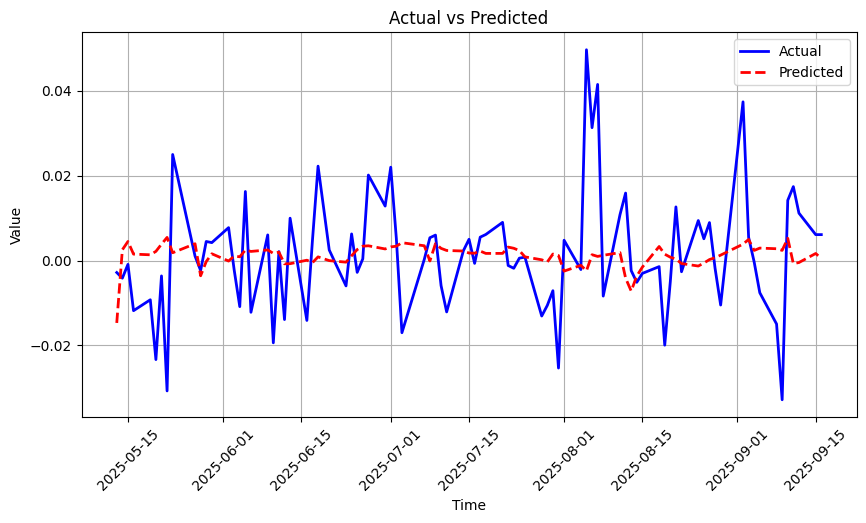

In [22]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_lstm[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_lstm[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Tuning Hyperparameter


In [23]:
class NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy/pandas types gracefully."""
    def default(self, obj):
        # numpy scalars / arrays
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()

        # pandas Series
        if isinstance(obj, pd.Series):
            return {
                "__type__": "pd.Series",
                "index": [
                    i.isoformat() if hasattr(i, "isoformat") else str(i)
                    for i in obj.index
                ],
                "values": obj.tolist(),
                "name": obj.name,
            }

        # pandas DataFrame
        if isinstance(obj, pd.DataFrame):
            df = obj.copy()
            if isinstance(df.index, pd.DatetimeIndex):
                df = df.reset_index().rename(columns={"index": "date"})
                df["date"] = df["date"].astype(str)
            return {
                "__type__": "pd.DataFrame",
                "columns": df.columns.tolist(),
                "data": df.to_dict(orient="records"),
            }

        # timestamps
        if isinstance(obj, pd.Timestamp):
            return obj.isoformat()
        if isinstance(obj, (datetime, date)):
            return obj.isoformat()

        return super().default(obj)


In [24]:
"""
Generate up to max_combinations random *unique* parameter combos (Random Search)

Args:
    param_grid: dict[str, list[Any]]  - parameter names mapped to value lists
    max_combinations: optional int - limit number of returned combinations, default 30

Returns:
    list[dict[str, Any]] - list of parameter dictionaries
"""
def random_search_params(param_grid, max_combinations=30):
    if not param_grid:
        return []

    keys = list(param_grid.keys())
    seen = set()
    combos = []

    # The theoretical max possible unique combos:
    max_possible = 1
    for k in keys:
        max_possible *= len(param_grid[k])

    target = min(max_combinations, max_possible)

    while len(combos) < target:
        combo = {k: random.choice(param_grid[k]) for k in keys}
        # convert to hashable
        as_tuple = tuple(sorted(combo.items()))
        if as_tuple not in seen:
            seen.add(as_tuple)
            combos.append(combo)

    return combos

In [25]:
"""
Tune each model in model_list by testing all hyperparameter combinations from its 'parameters' dict.
Selects the best by mean CV error. Saves per-model JSON + CSV, and returns a summary list.

model_list item schema:
  {
    'name': 'xgboost',
    'parameters': { ... },               # dict[str, list[Any]]
    'train_model': callable,             # (params, folds, ticker, X, y, dates) -> (preds, tests, scores)
    'max_combinations': 30               # optional int cap
  }
"""

def tuning(
    model_list: List[Dict[str, Any]],
    folds: List[Dict[str, np.ndarray]],
    ticker: str,
    X: np.ndarray,
    y: np.ndarray,
    dates: pd.Series,
    output_dir: str = "../results/tuning",
) -> List[Dict[str, Any]]:  # Returns list of best results per model

    # Create Output Directory
    os.makedirs(output_dir, exist_ok=True)

    # Remove any old files for this ticker in this directory ---
    # This will ensure don't accumulate multiple sets of files per ticker.
    patterns = [
        f"{ticker}_*_tuning.json",
        f"{ticker}_*_best_predictions.csv",
        f"{ticker}_MASTER_summary.json",
    ]
    for pattern in patterns:
        for path in glob.glob(os.path.join(output_dir, pattern)):
            try:
                os.remove(path)
                print(f"Deleted old file: {path}")
            except OSError as e:
                print(f"Could not delete {path}: {e}")
    # ------------------------------------------------------------------------------    

    best_results: List[Dict[str, Any]] = []
    master_summary: List[Dict[str, Any]] = []

    for base_model in model_list:
        name: str = base_model["name"]
        param_grid: Dict[str, List[Any]] = base_model["parameters"]
        train_model = base_model["train_model"]  # train_xgb & train_lstm
        limit: int | None = base_model.get("max_combinations")  # max combinations

        print(f"\n=== TUNING {name} on {ticker} ===")

        # Build param combos
        if not limit: 
            limit = 30
        param_combos = random_search_params(param_grid, max_combinations=limit)

        # Tracking var
        best_cv_error = float("inf")
        best_output: Tuple[List[pd.Series], List[pd.Series], List[float]] | None = None
        best_params: Dict[str, Any] | None = None
        all_results: List[Dict[str, Any]] = []

        # Loop through each combo
        for i, param_set in enumerate(param_combos, start=1):
            print(f"[{name}] combo {i}/{len(param_combos)}: {param_set}")

            # Train and evaluate for this combo
            preds, tests, scores = train_model(param_set, folds, ticker, X, y, dates)
            avg_error = float(np.mean(scores))  # avg rmse across ALL folds
            std_error = float(np.std(scores))

            all_results.append({
                "combination_id": i,
                "params": {k: (int(v) if isinstance(v, np.integer)
                               else float(v) if isinstance(v, np.floating)
                               else v)
                           for k, v in param_set.items()},  # Convert numpy types to Python types
                "cv_rmse_mean": avg_error,
                "cv_rmse_std": std_error,
                "cv_rmse_per_fold": [float(s) for s in scores],
            })

            if avg_error < best_cv_error:
                best_cv_error = avg_error
                best_output = (preds, tests, scores)
                best_params = dict(param_set)
                print(f"  ✅ NEW BEST (mean RMSE={best_cv_error})")

        # Save results for this model with BEST params
        if best_output is not None:
            preds_best, tests_best, scores_best = best_output

            # Concatenate predictions & actuals across all folds (aligned by date)
            preds_comb = pd.concat(preds_best).sort_index().rename("predicted")
            tests_comb = pd.concat(tests_best).sort_index().rename("actual")
            combined = pd.concat([preds_comb, tests_comb], axis=1).dropna()
            combined["error"] = combined["actual"] - combined["predicted"]

            # Prepare DataFrame for CSV
            combined_reset = combined.reset_index().rename(columns={"index": "date"})
            if np.issubdtype(combined_reset["date"].dtype, np.datetime64):
                combined_reset["date"] = pd.to_datetime(combined_reset["date"]).dt.date

            # Save a CSV with full best predictions 
            csv_path = os.path.join(output_dir, f"{ticker}_{name}_best_predictions.csv")
            combined_reset.to_csv(csv_path, index=False)

            # Build a small JSON-friendly preview (first 10 rows)
            preview = combined.head(10).copy()
            if isinstance(preview.index, pd.DatetimeIndex):
                preview = preview.reset_index().rename(columns={"index": "date"})
                preview["date"] = pd.to_datetime(preview["date"]).dt.date
            else:
                # still move index to a column named 'date' even if it's not datetime
                preview = preview.reset_index().rename(columns={"index": "date"})

            preview_dict = {
                "columns": preview.columns.tolist(),
                "data": preview.to_dict(orient="records"),
            }

            # create JSON with ALL info
            model_json = {
                "model": name,
                "ticker": ticker,
                "best_cv_rmse": float(best_cv_error),
                "best_params": best_params,
                "per_fold_scores": [float(s) for s in scores_best],
                "n_combinations_tested": len(all_results),
                "predictions_csv": csv_path,
                "combined_preview_head": preview_dict,
                "all_results": all_results,
            }

            # Save all combo tried
            json_path = os.path.join(output_dir, f"{ticker}_{name}_tuning.json")
            with open(json_path, "w") as f:
                json.dump(model_json, f, indent=2, cls=NumpyEncoder)

            print(f"✓ Saved {name} JSON → {json_path}")
            print(f"✓ Saved {name} predictions CSV → {csv_path}")

            best_results.append({
                "model": name,
                "best_params": best_params,
                "best_cv_rmse": float(best_cv_error),
                "best_output": best_output,     # (preds, tests, scores)
                "json_path": json_path,
                "csv_path": csv_path,
            })

            # Lighter version for best param JSON
            master_summary.append({
                "model": name,
                "best_cv_rmse": float(best_cv_error),
                "best_params": best_params,
                "json_path": json_path,
                "csv_path": csv_path,
            })
        else:
            print(f"⚠ No valid results for model: {name}")

    # Save Master summary
    master_path = os.path.join(output_dir, f"{ticker}_MASTER_summary.json")
    with open(master_path, "w") as f:
        json.dump({"ticker": ticker, "models": master_summary},
                  f, indent=2, cls=NumpyEncoder)
    print(f"\n✓ Saved MASTER summary → {master_path}")

    return best_results

In [26]:
LSTM_PARAMS = {
    'seq_len': [1, 3, 5],                     # lookback window for pred
    'hidden_dimension': [32, 64],             # number of hidden units in LSTM
    'layer_dimension': [1, 2],                # number of LSTM layers
    'fc1_dimension': [32, 64],                # first FC layer size
    'fc2_dimension': [16, 32],                # second FC layer size
    'dropout': [0, 0.1, 0.2, 0.3],            # Dropout rate
    'lr': [1e-4, 5e-4, 1e-3],                 # higher learning rates
    'num_epochs': [20],                       # number of forward propagations
    'batch_size': [32, 64],                   # mini-batch size
}

XGBOOST_PARAMS = {
    # == model cap ===
    'n_estimators': [300, 500, 1000],              # n-boosting rounds
    'max_depth': [4, 6, 8],                        # max depth of each decision trees
    'learning_rate': [0.01, 0.05, 0.1],
    # == randomness ==
    'subsample': [0.7, 0.8, 0.9],                  # training sample (fraction) used per tree
    'colsample_bytree': [0.7, 0.8, 0.9],          # fraction of feature used per tree
    # == split decision ==
    'min_child_weight': [1, 3, 5],                 # min sum of instances needed for a child node
    'gamma': [0, 0.1, 0.2],                        # min loss reduce to make a split
    # == regularization ==
    'reg_alpha': [0, 0.1, 0.3],                    # L1 Lasso -> some features get cancelled
    'reg_lambda': [1, 3],                       # L2 Ridge
}

In [29]:
model_list = [
    {
        "name": "xgboost",
        "parameters": XGBOOST_PARAMS,
        "train_model": lambda p, f, t, X_, y_, d: train_xgb(
            base_params=p, folds=f, X=X_, y=y_, dates=d
        ),
    },
    {
        "name": "lstm",
        "parameters": LSTM_PARAMS,
        "train_model": lambda p, f, t, X_, y_, d: train_lstm(
            base_params=p, folds=f, X=X_, y=y_, dates=d
        ),
        "max_combinations": 15,
    },
]

In [30]:
STOCK_LIST = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

# Store all results
all_stock_results = {}

for ticker in STOCK_LIST:
    print(f"\n{'='*80}")
    print(f"PROCESSING TICKER: {ticker}")
    print(f"{'='*80}\n")
    
    try:
        # Load data for this ticker
        TICKER = ticker
        X_raw = pd.read_csv(f"../data/selected/{TICKER}_X.csv")
        y_raw = pd.read_csv(f"../data/selected/{TICKER}_y.csv")
        dates = pd.to_datetime(X_raw["date"])
        X = X_raw.drop(columns="date").values
        y = np.ravel(y_raw.values)
        
        print(f"Loaded {ticker}: X shape = {X.shape}, y shape = {y.shape}")
        
        # Create time series folds for this ticker
        folds = createTimeSeriesSplit(data=X)
        print(f"Created {len(folds)} folds for {ticker}")
        
        # Run tuning for this ticker
        best_results = tuning(
            model_list=model_list,
            folds=folds,
            ticker=ticker,
            X=X, 
            y=y, 
            dates=dates,
            output_dir="../model/tuning",
        )
        
        # Store results
        all_stock_results[ticker] = best_results
        
        # Print summary for this ticker
        print(f"\n{'='*80}")
        print(f"COMPLETED: {ticker}")
        print(f"{'='*80}")
        for result in best_results:
            print(f"  {result['model']}: CV RMSE = {result['best_cv_rmse']}")
        print()
        
    except FileNotFoundError as e:
        print(f"❌ ERROR: Data files not found for {ticker}")
        print(f"   {str(e)}")
        all_stock_results[ticker] = None
        continue
        
    except Exception as e:
        print(f"❌ ERROR processing {ticker}: {str(e)}")
        import traceback
        traceback.print_exc()
        all_stock_results[ticker] = None


PROCESSING TICKER: AAPL

Loaded AAPL: X shape = (2139, 20), y shape = (2139,)
Created 5 folds for AAPL
Deleted old file: ../model/tuning/AAPL_lstm_tuning.json
Deleted old file: ../model/tuning/AAPL_xgboost_tuning.json
Deleted old file: ../model/tuning/AAPL_xgboost_best_predictions.csv
Deleted old file: ../model/tuning/AAPL_lstm_best_predictions.csv
Deleted old file: ../model/tuning/AAPL_MASTER_summary.json

=== TUNING xgboost on AAPL ===
[xgboost] combo 1/30: {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 5, 'gamma': 0.2, 'reg_alpha': 0.3, 'reg_lambda': 3}
  ✅ NEW BEST (mean RMSE=0.01686830986371165)
[xgboost] combo 2/30: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'gamma': 0.2, 'reg_alpha': 0.1, 'reg_lambda': 3}
  ✅ NEW BEST (mean RMSE=0.016868244534499952)
[xgboost] combo 3/30: {'n_estimators': 1000, 'max_depth': 8, 'learning_